In [ ]:
import kagglehub
path=kagglehub.dataset_download("prachi13/customer-analytics")
print("Path to dataset files:",path)

Using Colab cache for faster access to the 'customer-analytics' dataset.
Path to dataset files: /kaggle/input/customer-analytics


In [ ]:
import pandas as pd
df=pd.read_csv("/kaggle/input/customer-analytics/Train.csv")

In [ ]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [ ]:
df.columns.to_list()

['ID',
 'Warehouse_block',
 'Mode_of_Shipment',
 'Customer_care_calls',
 'Customer_rating',
 'Cost_of_the_Product',
 'Prior_purchases',
 'Product_importance',
 'Gender',
 'Discount_offered',
 'Weight_in_gms',
 'Reached.on.Time_Y.N']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [ ]:
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [ ]:
# 1. Top 5 heaviest products with their cost
df[['Cost_of_the_Product','Weight_in_gms']].nlargest(5,'Weight_in_gms')

,Cost_of_the_Product,Weight_in_gms
199,154,7846
245,154,7684
198,142,7640
205,145,7588
213,160,7401


In [ ]:
# 2. Minimum discount offered
df['Discount_offered'].min()


1

In [ ]:
# 3. Average weight of products shipped by Road
df[df['Mode_of_Shipment']=='Road']['Weight_in_gms'].mean()

np.float64(3649.550568181818)

In [ ]:
# 4. Count of on-time vs delayed deliveries
df['Reached.on.Time_Y.N'].value_counts()


,count
Reached.on.Time_Y.N,
1,6563
0,4436


In [ ]:
# 5. Highest final price product
(df['Cost_of_the_Product'] - df['Discount_offered']).nlargest(1)

,0
4819,309


In [ ]:
# 6. Distribution of Product Importance by shipment mode
df.groupby(['Mode_of_Shipment','Product_importance']).size().unstack()

Product_importance,high,low,medium
Mode_of_Shipment,,,
Flight,163,838,776
Road,158,857,745
Ship,627,3602,3233


In [ ]:
# 7. Average discount given for on-time vs delayed deliveries
df.groupby('Reached.on.Time_Y.N')['Discount_offered'].mean()


,Discount_offered
Reached.on.Time_Y.N,
0,5.545987
1,18.663721


In [ ]:
# 8. Correlation matrix for numeric columns
df.corr(numeric_only=True)

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
ID,1.000000,0.188998,-0.005722,0.196791,0.145369,-0.598278,0.278312,-0.411822
Customer_care_calls,0.188998,1.000000,0.012209,0.323182,0.180771,-0.130750,-0.276615,-0.067126
Customer_rating,-0.005722,0.012209,1.000000,0.009270,0.013179,-0.003124,-0.001897,0.013119
Cost_of_the_Product,0.196791,0.323182,0.009270,1.000000,0.123676,-0.138312,-0.132604,-0.073587
Prior_purchases,0.145369,0.180771,0.013179,0.123676,1.000000,-0.082769,-0.168213,-0.055515
Discount_offered,-0.598278,-0.130750,-0.003124,-0.138312,-0.082769,1.000000,-0.376067,0.397108
Weight_in_gms,0.278312,-0.276615,-0.001897,-0.132604,-0.168213,-0.376067,1.000000,-0.268793
Reached.on.Time_Y.N,-0.411822,-0.067126,0.013119,-0.073587,-0.055515,0.397108,-0.268793,1.000000


In [ ]:
# 9. Percentage of products delivered late
(df[df['Reached.on.Time_Y.N']==0].shape[0] / df.shape[0]) * 100

40.33093917628875

In [ ]:
# 10. Pivot: Average weight grouped by product importance & shipment mode
df.pivot_table(
    values='Weight_in_gms',
    index='Product_importance',
    columns='Mode_of_Shipment',
    aggfunc='mean'
)

Mode_of_Shipment,Flight,Road,Ship
Product_importance,,,
high,4069.871166,3974.487342,3996.658692
low,3536.021480,3498.372229,3488.314270
medium,3637.667526,3754.543624,3720.112280


In [ ]:
# Create a new column for cost per gram
df['Cost_per_gram'] = df.apply(lambda x: x['Cost_of_the_Product'] / x['Weight_in_gms'], axis=1)
print(df['Cost_per_gram'])

0        0.143552
1        0.069948
2        0.054238
3        0.149533
4        0.074074
           ...   
10994    0.163849
10995    0.186047
10996    0.209524
10997    0.184298
10998    0.094570
Name: Cost_per_gram, Length: 10999, dtype: float64


In [ ]:
# Convert Gender into numeric: Male=1, Female=0
df['Gender_num'] = df['Gender'].map(lambda x: 1 if x=='M' else 0)
print(df['Gender_num'])

0        0
1        1
2        1
3        1
4        0
        ..
10994    0
10995    0
10996    0
10997    1
10998    0
Name: Gender_num, Length: 10999, dtype: int64


In [ ]:
# Products with both high cost and high discount
df.query("Cost_of_the_Product > 200 and Discount_offered > 10")

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Cost_per_gram,Gender_num
1,2,F,Flight,4,5,216,2,low,M,59,3088,1,0.069948,1
7,8,F,Flight,4,1,233,2,low,F,48,2804,1,0.083096,0
11,12,F,Flight,4,5,232,3,medium,F,32,3253,1,0.071319,0
13,14,F,Flight,4,4,275,3,high,M,29,2602,1,0.105688,1
15,16,B,Flight,4,3,227,3,low,F,45,2707,1,0.083857,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3126,3127,D,Road,3,1,224,3,low,F,48,3672,1,0.061002,0
3129,3130,B,Road,3,4,248,2,medium,F,15,2983,1,0.083138,0
3130,3131,C,Road,6,5,246,4,medium,M,50,3618,1,0.067993,1
3131,3132,F,Road,4,1,232,3,medium,M,55,2686,1,0.086374,1


In [ ]:
# Max cost product per warehouse
df.groupby('Warehouse_block').apply(lambda x: x.loc[x['Cost_of_the_Product'].idxmax()])


/tmp/ipython-input-1508874493.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Warehouse_block').apply(lambda x: x.loc[x['Cost_of_the_Product'].idxmax()])


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Cost_per_gram,Gender_num
Warehouse_block,,,,,,,,,,,,,,
A,5025,A,Ship,7,2,310,4,low,F,7,1294,0,0.239567,0
B,4552,B,Ship,6,2,310,4,medium,F,5,1791,1,0.173088,0
C,4565,C,Ship,6,3,310,4,low,F,2,1817,0,0.170611,0
D,5041,D,Ship,7,3,310,4,medium,F,7,1989,0,0.155857,0
F,4820,F,Ship,6,5,310,4,medium,M,1,1105,1,0.280543,1


In [ ]:
df.groupby('Mode_of_Shipment').agg(
    mean_cost = ('Cost_of_the_Product', lambda x: x.mean()),
    total_discount = ('Discount_offered', lambda x: x.sum())
)

,mean_cost,total_discount
Mode_of_Shipment,,
Flight,209.306697,23387
Road,210.475568,23028
Ship,210.343072,100677


In [ ]:
# Rank products by weight within each shipment mode
df['Weight_Rank'] = df.groupby('Mode_of_Shipment')['Weight_in_gms'].transform(lambda x: x.rank(ascending=False))
print(df['Weight_Rank'])

0        1662.0
1        1104.0
2        1067.0
3        1686.5
4        1193.5
          ...  
10994    6236.5
10995    6865.5
10996    7093.5
10997    6963.0
10998    6027.0
Name: Weight_Rank, Length: 10999, dtype: float64


In [ ]:
# Correlation per shipment mode
df.groupby('Mode_of_Shipment').apply(lambda x: x[['Cost_of_the_Product','Discount_offered','Weight_in_gms']].corr())

/tmp/ipython-input-961362738.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Mode_of_Shipment').apply(lambda x: x[['Cost_of_the_Product','Discount_offered','Weight_in_gms']].corr())


Cost_of_the_Product  Discount_offered  \
Mode_of_Shipment                                                              
Flight           Cost_of_the_Product             1.000000         -0.127529   
                 Discount_offered               -0.127529          1.000000   
                 Weight_in_gms                  -0.152166         -0.380866   
Road             Cost_of_the_Product             1.000000         -0.132167   
                 Discount_offered               -0.132167          1.000000   
                 Weight_in_gms                  -0.145160         -0.401947   
Ship             Cost_of_the_Product             1.000000         -0.142284   
                 Discount_offered               -0.142284          1.000000   
                 Weight_in_gms                  -0.125212         -0.369104   

                                      Weight_in_gms  
Mode_of_Shipment                                     
Flight           Cost_of_the_Product      -0.152166  
                 Discount_offered         -0.380866  
                 Weight_in_gms             1.000000  
Road             Cost_of_the_Product      -0.145160  
                 Discount_offered         -0.401947  
                 Weight_in_gms             1.000000  
Ship             Cost_of_the_Product      -0.125212  
                 Discount_offered         -0.369104  
                 Weight_in_gms             1.000000

In [ ]:
# Summary statistics for numerical columns
print(df['Cost_of_the_Product'].describe())

# Frequency counts for categorical column
print(df['Mode_of_Shipment'].value_counts())

# Skewness & Kurtosis
# Skewness measures the asymmetry of the data distribution around the mean.
# Kurtosis This measures the "tailedness" of the distribution
print("Skewness:", df['Cost_of_the_Product'].skew())
print("Kurtosis:", df['Cost_of_the_Product'].kurt())

count    10999.000000
mean       210.196836
std         48.063272
min         96.000000
25%        169.000000
50%        214.000000
75%        251.000000
max        310.000000
Name: Cost_of_the_Product, dtype: float64
Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64
Skewness: -0.15711711926913643
Kurtosis: -0.9721602891279231


In [ ]:
# Pearson correlation (linear relationship)
print(df[['Cost_of_the_Product', 'Weight_in_gms']].corr(method='pearson'))

# Spearman correlation (monotonic relationship, useful for ranks)
print(df[['Cost_of_the_Product', 'Discount_offered']].corr(method='spearman'))

                     Cost_of_the_Product  Weight_in_gms
Cost_of_the_Product             1.000000      -0.132604
Weight_in_gms                  -0.132604       1.000000
                     Cost_of_the_Product  Discount_offered
Cost_of_the_Product             1.000000         -0.115817
Discount_offered               -0.115817          1.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

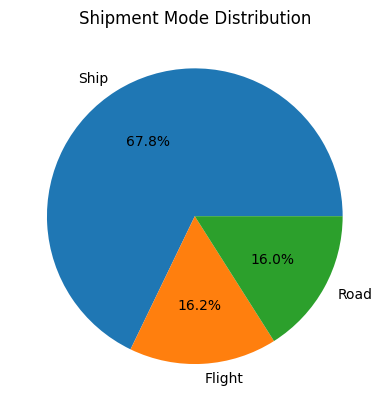

In [ ]:
# 1. Pie chart - Shipment mode distribution
shipment_counts = df['Mode_of_Shipment'].value_counts()
plt.pie(shipment_counts, labels=shipment_counts.index, autopct='%1.1f%%')
plt.title("Shipment Mode Distribution")
plt.show()

Helps you understand which shipping method is most commonly used by customers.

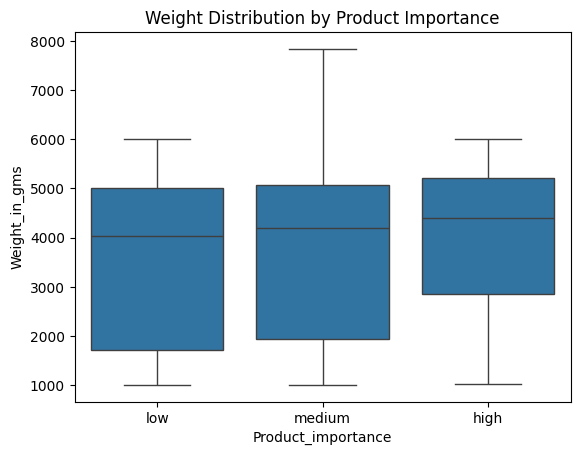

In [ ]:
# 2. Boxplot - Weight by product importance
sns.boxplot(x='Product_importance', y='Weight_in_gms', data=df)
plt.title("Weight Distribution by Product Importance")
plt.show()


Compare product weights across “Low”, “Medium”, “High” importance.

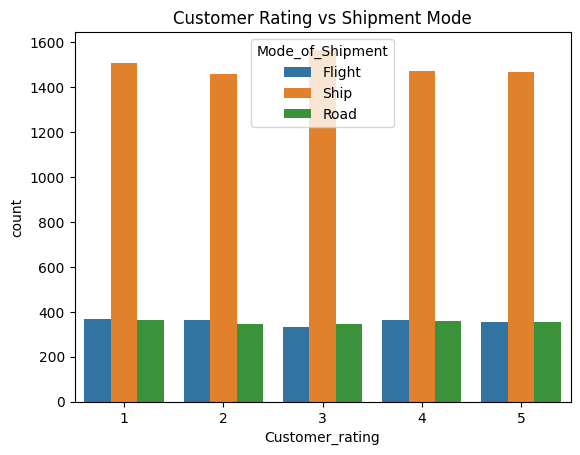

In [ ]:
# 3. Countplot - Customer Rating by Shipment Mode
sns.countplot(x='Customer_rating', hue='Mode_of_Shipment', data=df)
plt.title("Customer Rating vs Shipment Mode")
plt.show()

Distribution of ratings (1–5) across shipment modes.

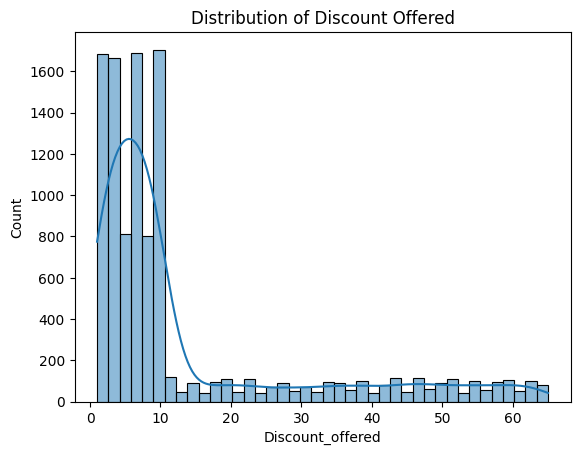

In [ ]:
# 4. Histogram - Discount Offered
sns.histplot(df['Discount_offered'], bins=40, kde=True)
plt.title("Distribution of Discount Offered")
plt.show()

Shows how discounts are spread.

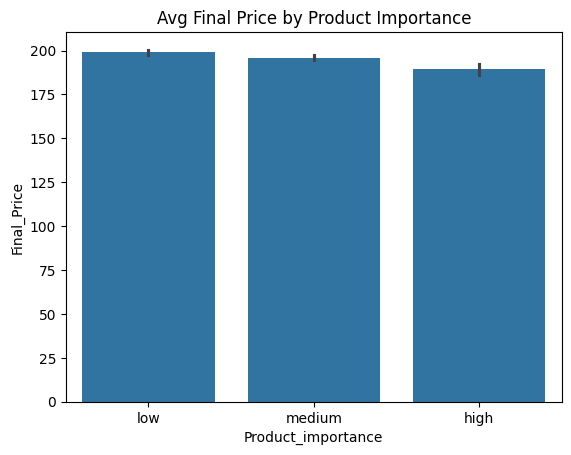

In [ ]:
# 6. Barplot - Average Final Price by Product Importance
# Calculate the final price
df['Final_Price'] = df['Cost_of_the_Product'] - df['Discount_offered']

# Plot the average final price by product importance
sns.barplot(x='Product_importance', y='Final_Price', data=df)
plt.title("Avg Final Price by Product Importance")
plt.show()

Compares average price for “Low/Medium/High” importance.

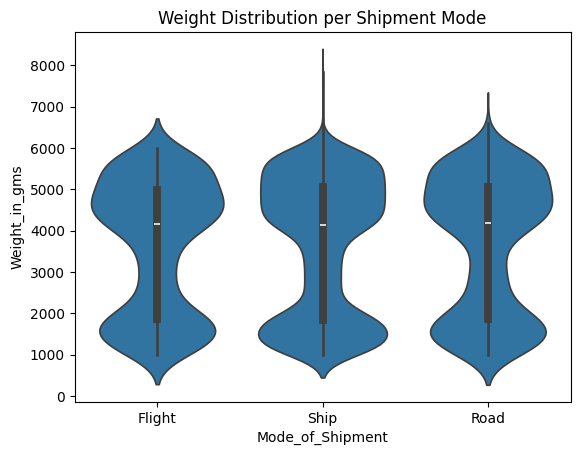

In [ ]:
# 7. Violinplot - Weight by Shipment Mode
sns.violinplot(x='Mode_of_Shipment', y='Weight_in_gms', data=df)
plt.title("Weight Distribution per Shipment Mode")
plt.show()

Distribution shape of weights for each shipment mode.

/tmp/ipython-input-3357240083.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Prior_purchases', y='Cost_of_the_Product', data=df, ci=None)


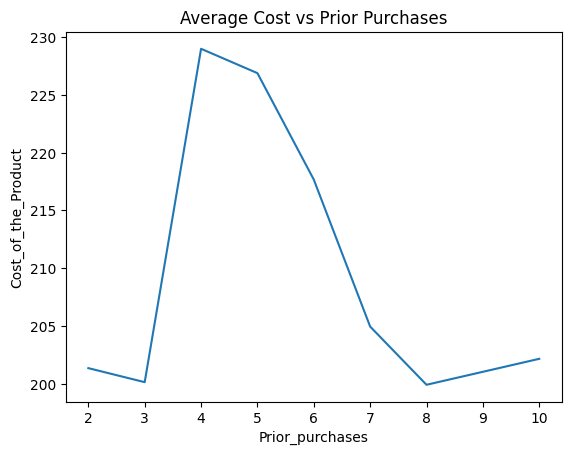

In [ ]:
# 8. Lineplot - Average Cost across Prior Purchases
sns.lineplot(x='Prior_purchases', y='Cost_of_the_Product', data=df, ci=None)
plt.title("Average Cost vs Prior Purchases")
plt.show()

Relationship between loyalty (purchases) and product cost.

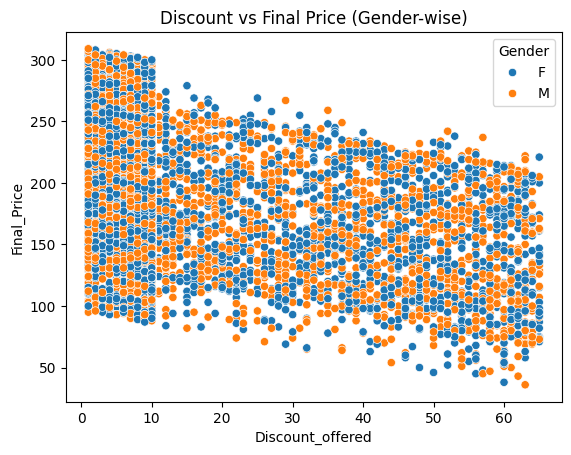

In [ ]:
# 9. Scatterplot - Discount vs Final Price (color by Gender)
sns.scatterplot(x='Discount_offered', y='Final_Price', hue='Gender', data=df)
plt.title("Discount vs Final Price (Gender-wise)")
plt.show()

How discounts are given across price levels & genders.

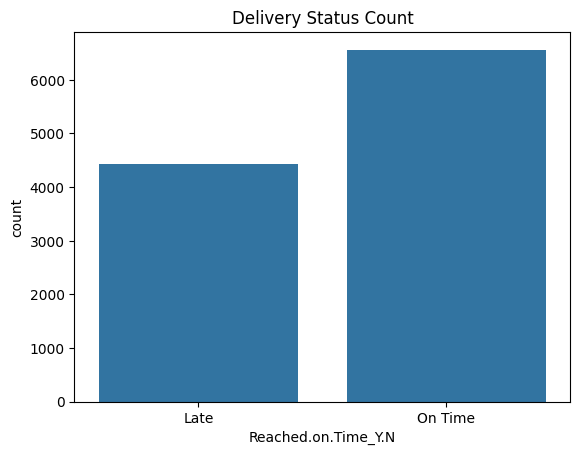

In [ ]:
# 10. Barplot - Late vs On-time Deliveries
sns.countplot(x='Reached.on.Time_Y.N', data=df)
plt.xticks([0,1], ['Late','On Time'])
plt.title("Delivery Status Count")
plt.show()


Total late vs on-time deliveries.

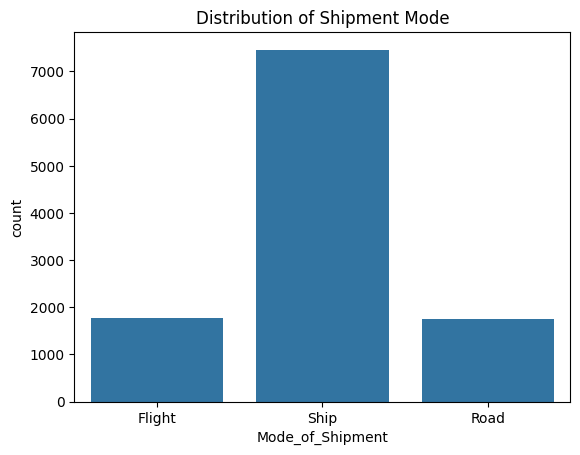

In [ ]:
# Distribution of shipment mode
sns.countplot(x='Mode_of_Shipment', data=df)
plt.title("Distribution of Shipment Mode")
plt.show()


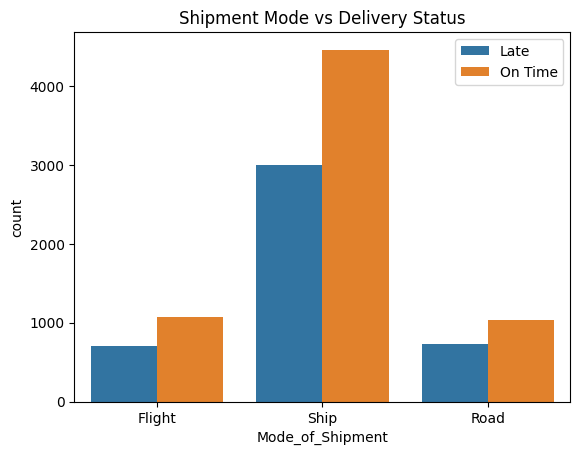

In [ ]:
# Delivery status by shipment mode
sns.countplot(x='Mode_of_Shipment', hue='Reached.on.Time_Y.N', data=df)
plt.title("Shipment Mode vs Delivery Status")
plt.legend(labels=['Late','On Time'])
plt.show()

Handle Missing Values

In [ ]:
# Check missing values
print(df.isnull().sum())

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
Cost_per_gram          0
Gender_num             0
Weight_Rank            0
Final_Price            0
dtype: int64


In [ ]:
# Since dataset has no missing values, no imputation needed

Encode Categorical Variables

In [ ]:
# Mode_of_Shipment: One-Hot Encoding
df = pd.get_dummies(df, columns=['Mode_of_Shipment'], drop_first=True)

# Product_importance: Ordinal Encoding
importance_map = {'low': 1, 'medium': 2, 'high': 3}
df['Product_importance_num'] = df['Product_importance'].map(importance_map)

# Gender already encoded as Gender_num

Normalize Numerical Features

In [ ]:
from sklearn.preprocessing import MinMaxScaler

num_cols = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
            'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'Cost_per_gram']

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


In [ ]:
#  Interaction feature
df['Cost_x_Weight'] = df['Cost_of_the_Product'] * df['Weight_in_gms']


Split Dataset for Modeling

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Reached.on.Time_Y.N', 'ID', 'Product_importance', 'Gender', 'Warehouse_block', 'Mode_of_Shipment'])
y = df['Reached.on.Time_Y.N']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape, "Test set:", X_test.shape)

Training set: (8799, 6) Test set: (2200, 6)


In [ ]:
#Common imports + CV setup (run once)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score, RocCurveDisplay,
                             classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Prepare a results container
results = {}


Best LR params: {'C': 1, 'solver': 'liblinear'}
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.58      0.56       887
           1       0.70      0.67      0.69      1313

    accuracy                           0.64      2200
   macro avg       0.62      0.63      0.62      2200
weighted avg       0.64      0.64      0.64      2200



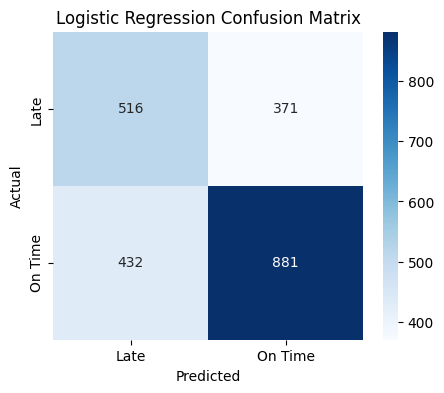

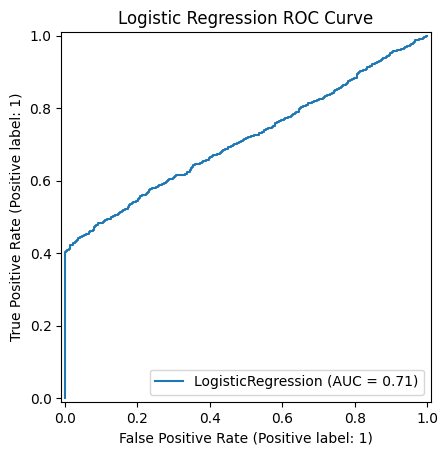

In [ ]:
#  Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}

lr_grid = GridSearchCV(lr, lr_params, cv=cv, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train, y_train)
best_lr = lr_grid.best_estimator_

print("Best LR params:", lr_grid.best_params_)

# Evaluate
y_pred = best_lr.predict(X_test)
y_proba = best_lr.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Late','On Time'], yticklabels=['Late','On Time'])
plt.title("Logistic Regression Confusion Matrix")
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()

# ROC
RocCurveDisplay.from_estimator(best_lr, X_test, y_test)
plt.title("Logistic Regression ROC Curve")
plt.show()

results['Logistic Regression'] = [acc, prec, rec, f1, roc_auc]


Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.70      0.62       887
           1       0.76      0.63      0.69      1313

    accuracy                           0.66      2200
   macro avg       0.66      0.67      0.66      2200
weighted avg       0.68      0.66      0.66      2200



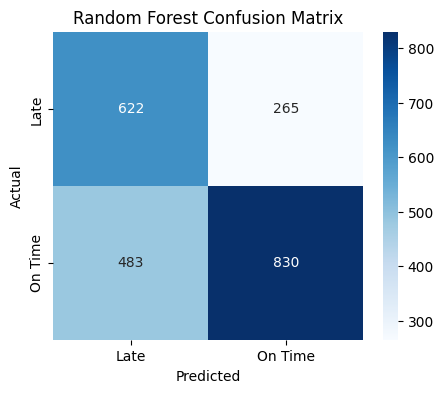

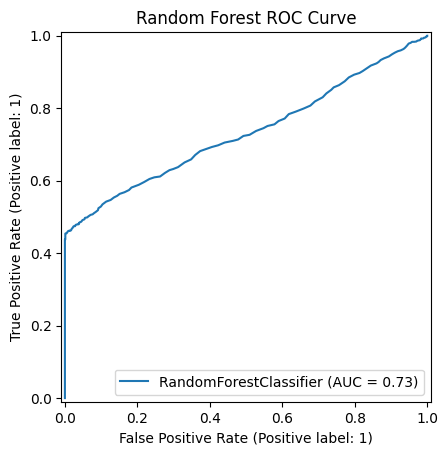

In [ ]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf_params = {'n_estimators': [100, 200], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5]}

rf_grid = GridSearchCV(rf, rf_params, cv=cv, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

print("Best RF params:", rf_grid.best_params_)

# Evaluate
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Late','On Time'], yticklabels=['Late','On Time'])
plt.title("Random Forest Confusion Matrix")
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()

RocCurveDisplay.from_estimator(best_rf, X_test, y_test)
plt.title("Random Forest ROC Curve")
plt.show()

results['Random Forest'] = [acc, prec, rec, f1, roc_auc]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:35:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.55      0.57       887
           1       0.71      0.73      0.72      1313

    accuracy                           0.66      2200
   macro avg       0.64      0.64      0.64      2200
weighted avg       0.66      0.66      0.66      2200



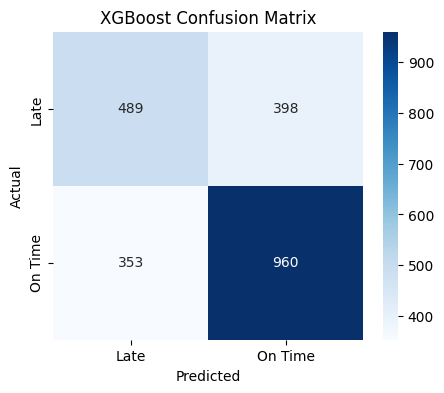

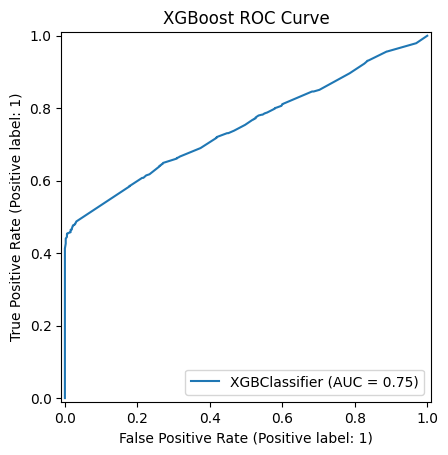

In [ ]:
#  XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_params = {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1]}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=cv, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

print("Best XGB params:", xgb_grid.best_params_)

# Evaluate
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Late','On Time'], yticklabels=['Late','On Time'])
plt.title("XGBoost Confusion Matrix")
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()

RocCurveDisplay.from_estimator(best_xgb, X_test, y_test)
plt.title("XGBoost ROC Curve")
plt.show()

results['XGBoost'] = [acc, prec, rec, f1, roc_auc]


Accuracy: 0.6481818181818182
Precision: 0.9786856127886323
Recall: 0.41964965727341963
F1 Score: 0.5874200426439232
ROC-AUC: 0.7315329919948894

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.99      0.69       887
           1       0.98      0.42      0.59      1313

    accuracy                           0.65      2200
   macro avg       0.76      0.70      0.64      2200
weighted avg       0.80      0.65      0.63      2200



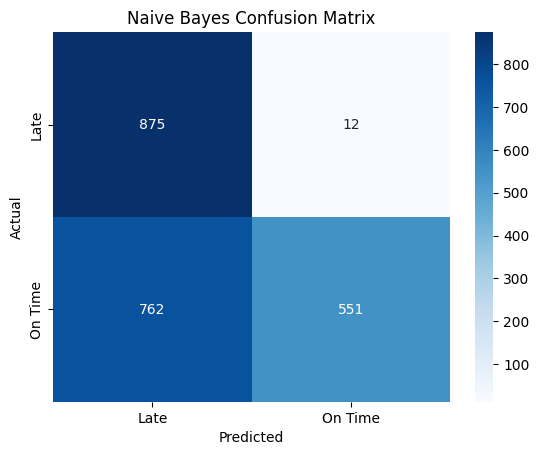

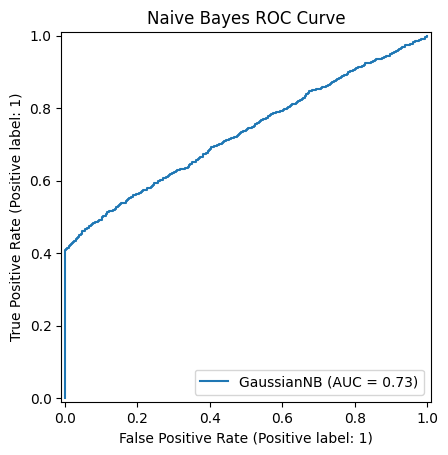

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Define model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predictions
y_pred = nb.predict(X_test)
y_proba = nb.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Late','On Time'], yticklabels=['Late','On Time'])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Naive Bayes Confusion Matrix")
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(nb, X_test, y_test)
plt.title("Naive Bayes ROC Curve")
plt.show()

# Save results
results['NaiveBayes'] = [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
                         recall_score(y_test, y_pred), f1_score(y_test, y_pred), roc_auc_score(y_test, y_proba)]


SVM Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.18      0.28       887
           1       0.62      0.91      0.74      1313

    accuracy                           0.62      2200
   macro avg       0.61      0.55      0.51      2200
weighted avg       0.61      0.62      0.56      2200

Accuracy: 0.6191, Precision: 0.6236, Recall: 0.9124, F1: 0.7409, ROC-AUC: 0.7005


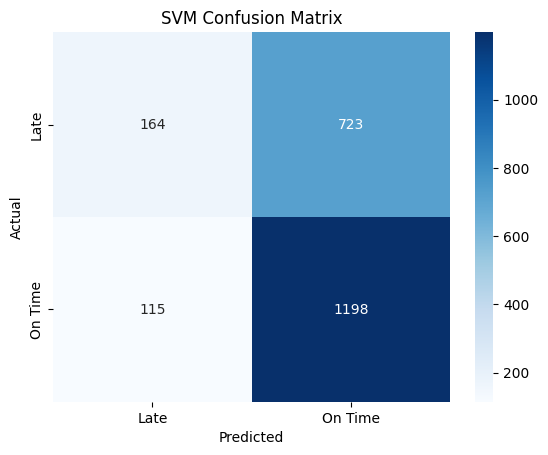

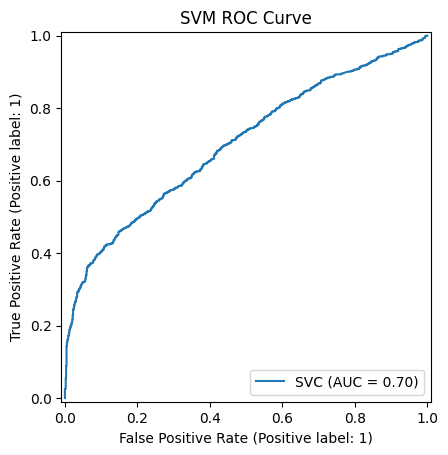

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# 1. Define a fast SVM model
# =============================
svc = SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42)

# =============================
# 2. Train the model
# =============================
svc.fit(X_train, y_train)

# =============================
# 3. Make predictions
# =============================
y_pred = svc.predict(X_test)
y_proba = svc.predict_proba(X_test)[:, 1]

# =============================
# 4. Evaluation metrics
# =============================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("SVM Classification Report:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")

# =============================
# 5. Confusion Matrix
# =============================
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Late','On Time'], yticklabels=['Late','On Time'])
plt.title("SVM Confusion Matrix")
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

# =============================
# 6. ROC Curve
# =============================
RocCurveDisplay.from_estimator(svc, X_test, y_test)
plt.title("SVM ROC Curve")
plt.show()

# =============================
# 7. Save results
# =============================
results['SVM'] = [acc, prec, rec, f1, roc_auc]


In [ ]:
#Compare model performance (summary table)

results_df = pd.DataFrame(results, index=['Accuracy','Precision','Recall','F1-Score','ROC-AUC']).T
display(results_df.sort_values(by='F1-Score', ascending=False))


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
SVM,0.619091,0.623634,0.912414,0.740878,0.700548
Logistic Regression,0.648636,0.683673,0.765423,0.722242,0.729895
XGBoost,0.658636,0.706922,0.731150,0.718832,0.750891
Random Forest,0.660000,0.757991,0.632140,0.689369,0.732672
NaiveBayes,0.653182,0.885154,0.481340,0.623582,0.735078
